In [1]:
import os
import random
import numpy as np
import cv2
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam


In [2]:
BASE_PATH = r"E:\OilSpillData"   # change if needed

IMG_DIR  = os.path.join(BASE_PATH, "train", "images")
MASK_DIR = os.path.join(BASE_PATH, "train", "masks")

print("Images:", len(os.listdir(IMG_DIR)))
print("Masks :", len(os.listdir(MASK_DIR)))


Images: 349
Masks : 349


In [3]:
def preprocess_image(path, size=(256,256)):
    img = imageio.imread(path)

    # take single SAR band if multi-channel
    if img.ndim == 3:
        img = img[:, :, 0]

    img = cv2.resize(img, size)
    img = img.astype(np.float32)

    # SAFE normalization
    min_val = img.min()
    max_val = img.max()
    if max_val > min_val:
        img = (img - min_val) / (max_val - min_val)
    else:
        img = np.zeros_like(img)

    img = np.expand_dims(img, axis=-1)
    return img


def preprocess_mask(path, size=(256,256)):
    mask = imageio.imread(path)

    if mask.ndim == 3:
        mask = mask[:, :, 0]

    mask = cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.float32)   # binary
    mask = np.expand_dims(mask, axis=-1)
    return mask


In [4]:
def speckle_filter(img):
    img2d = img.squeeze()
    img2d = cv2.medianBlur((img2d * 255).astype(np.uint8), 3)
    img2d = img2d.astype(np.float32) / 255.0
    return np.expand_dims(img2d, axis=-1)


In [5]:
def augment(image, mask):
    if random.random() > 0.5:
        image = np.fliplr(image)
        mask  = np.fliplr(mask)

    if random.random() > 0.5:
        image = np.flipud(image)
        mask  = np.flipud(mask)

    return image, mask


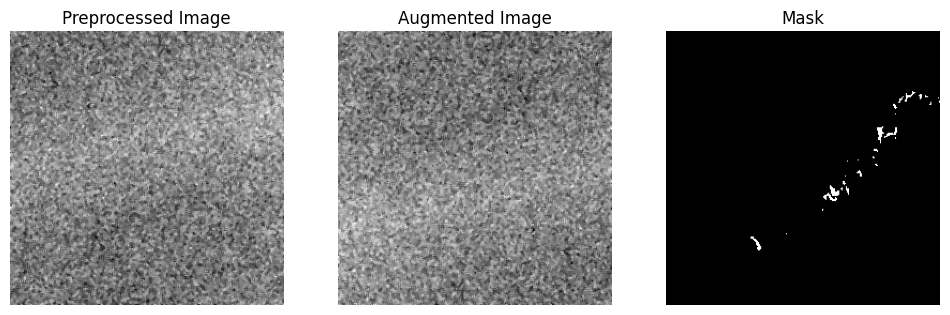

Image shape: (256, 256, 1)
Mask shape : (256, 256, 1)
Mask unique: [0. 1.]


In [8]:
img_name = random.choice(os.listdir(IMG_DIR))

img_p  = preprocess_image(os.path.join(IMG_DIR, img_name))
mask_p = preprocess_mask(os.path.join(MASK_DIR, img_name))

img_p = speckle_filter(img_p)

aug_img, aug_mask = augment(img_p, mask_p)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Preprocessed Image")
plt.imshow(img_p.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Augmented Image")
plt.imshow(aug_img.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Mask")
plt.imshow(mask_p.squeeze(), cmap="gray")
plt.axis("off")

plt.show()

print("Image shape:", img_p.shape)
print("Mask shape :", mask_p.shape)
print("Mask unique:", np.unique(mask_p))


In [9]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)


In [10]:
def build_unet(input_shape=(256,256,1)):
    inputs = tf.keras.layers.Input(input_shape)

    c1 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D()(c1)

    c2 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D()(c2)

    c3 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(c3)

    u4 = tf.keras.layers.UpSampling2D()(c3)
    u4 = tf.keras.layers.Concatenate()([u4, c2])
    c4 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(u4)

    u5 = tf.keras.layers.UpSampling2D()(c4)
    u5 = tf.keras.layers.Concatenate()([u5, c1])
    c5 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(u5)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(c5)

    return tf.keras.Model(inputs, outputs)


In [11]:
model = build_unet()

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[
        dice_coef,
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 256, 256, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 256, 256, 32)      │             320 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 256, 256, 32)      │           9,248 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 128, 128, 32)      │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 128, 128, 64)      │          18,496 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 128, 128, 64)      │          36,928 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 64, 64, 64)        │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 64, 64, 128)       │          73,856 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 64, 64, 128)       │         147,584 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d (UpSampling2D)  │ (None, 128, 128, 128)     │               0 │ conv2d_5[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 128, 128, 192)     │               0 │ up_sampling2d[0][0],       │
│                               │                           │                 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 128, 128, 64)      │         110,656 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_1               │ (None, 256, 256, 64)      │               0 │ conv2d_6[0][0]             │
│ (UpSampling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 256, 256, 96)      │               0 │ up_sampling2d_1[0][0],     │
│                               │                           │                 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 256, 256, 32)      │          27,680 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 424,801 (1.62 MB)

 Trainable params: 424,801 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
image_list = []
mask_list = []

for f in os.listdir(IMG_DIR):
    mask_path = os.path.join(MASK_DIR, f)
    if not os.path.exists(mask_path):
        continue

    mask = imageio.imread(mask_path)
    if np.any(mask > 0):   # keep images with oil
        image_list.append(f)
        mask_list.append(f)

print("Training samples with oil spills:", len(image_list))


Training samples with oil spills: 149


In [13]:
def data_generator(img_names, batch_size=4):
    while True:
        idxs = np.random.permutation(len(img_names))

        for i in range(0, len(idxs), batch_size):
            batch_idxs = idxs[i:i+batch_size]

            imgs, masks = [], []

            for j in batch_idxs:
                name = img_names[j]

                img = preprocess_image(os.path.join(IMG_DIR, name))
                mask = preprocess_mask(os.path.join(MASK_DIR, name))

                img = speckle_filter(img)
                img, mask = augment(img, mask)

                imgs.append(img)
                masks.append(mask)

            yield np.array(imgs), np.array(masks)


In [14]:
BATCH_SIZE = 4
EPOCHS = 25

steps_per_epoch = len(image_list) // BATCH_SIZE

train_gen = data_generator(image_list, BATCH_SIZE)

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS
)


Epoch 1/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 206s 5s/step - accuracy: 0.0280 - dice_coef: 0.0515 - loss: 0.9485 - precision: 0.0277 - recall: 1.0000
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.0928 - dice_coef: 0.0500 - loss: 0.9490 - precision: 0.0282 - recall: 0.9526
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.1868 - dice_coef: 0.0516 - loss: 0.9477 - precision: 0.0295 - recall: 0.8918
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.3204 - dice_coef: 0.0464 - loss: 0.9533 - precision: 0.0251 - recall: 0.7195
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.1780 - dice_coef: 0.0604 - loss: 0.9386 - precision: 0.0335 - recall: 0.8945
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.2880 - dice_coef: 0.0545 - loss: 0.9447 - precision: 0.0304 - recall: 0.8038
Epoch 7/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.0406 - dice_coef: 0.0531 - loss: 0.9478 - precision: 0.0273 - recall: 0.9970
Epoch 8/25
3

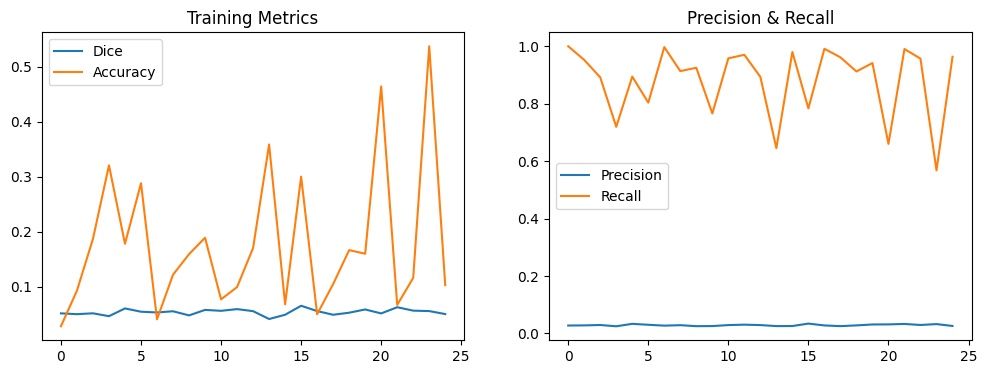

In [15]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['dice_coef'], label='Dice')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.legend()
plt.title("Training Metrics")

plt.subplot(1,2,2)
plt.plot(history.history['precision'], label='Precision')
plt.plot(history.history['recall'], label='Recall')
plt.legend()
plt.title("Precision & Recall")

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


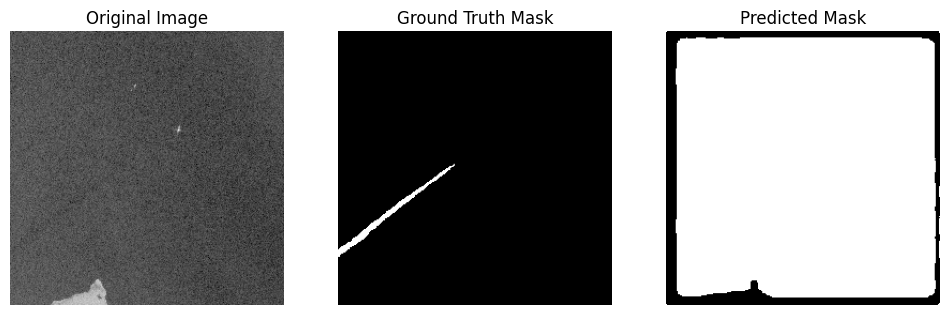

In [16]:
test_img_name = random.choice(image_list)

img = preprocess_image(os.path.join(IMG_DIR, test_img_name))
mask = preprocess_mask(os.path.join(MASK_DIR, test_img_name))

pred = model.predict(np.expand_dims(img, axis=0))[0]
pred_bin = (pred > 0.3).astype(np.float32)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img.squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(mask.squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred_bin.squeeze(), cmap='gray')
plt.axis('off')

plt.show()


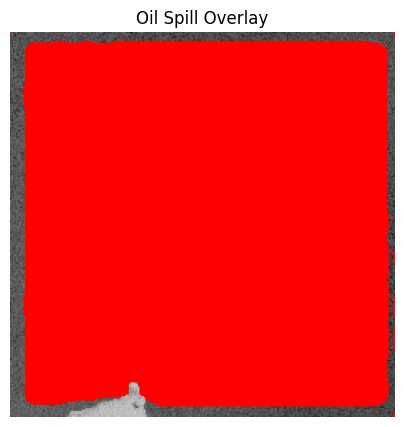

In [17]:
overlay = img.squeeze().copy()
overlay = np.stack([overlay]*3, axis=-1)

overlay[pred_bin.squeeze() == 1] = [1, 0, 0]  # red overlay

plt.figure(figsize=(5,5))
plt.title("Oil Spill Overlay")
plt.imshow(overlay)
plt.axis("off")
plt.show()


In [18]:

model.save("oil_spill_unet.keras")
print("Model saved successfully")


Model saved successfully


In [19]:
def iou_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.3, tf.float32)  # threshold
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

# Test all images in dataset (or pick subset)
dice_scores = []
iou_scores = []

for img_name in image_list:
    img = preprocess_image(os.path.join(IMG_DIR, img_name))
    mask = preprocess_mask(os.path.join(MASK_DIR, img_name))

    pred = model.predict(np.expand_dims(img, axis=0))[0]
    pred_bin = (pred > 0.3).astype(np.float32)

    dice = dice_coef(mask, pred_bin).numpy()
    iou  = iou_coef(mask, pred_bin).numpy()

    dice_scores.append(dice)
    iou_scores.append(iou)

print("Average Dice:", np.mean(dice_scores))
print("Average IoU :", np.mean(iou_scores))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [20]:
SAVE_DIR = os.path.join(BASE_PATH, "predictions")
os.makedirs(SAVE_DIR, exist_ok=True)

for img_name in image_list[:10]:   # save first 10 predictions
    img = preprocess_image(os.path.join(IMG_DIR, img_name))
    pred = model.predict(np.expand_dims(img, axis=0))[0]
    pred_bin = (pred > 0.3).astype(np.uint8) * 255

    save_path = os.path.join(SAVE_DIR, img_name)
    cv2.imwrite(save_path, pred_bin)

print("Predictions saved to folder:", SAVE_DIR)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step
Predictions saved to folder: E:\OilSpillData\predictions


In [21]:
import matplotlib.pyplot as plt

# Folder to save overlay figures
OVERLAY_DIR = os.path.join(BASE_PATH, "overlay_figures")
os.makedirs(OVERLAY_DIR, exist_ok=True)

# Pick a few test images (or all)
test_images = image_list[:10]  # first 10 for example

for img_name in test_images:
    # Load and preprocess
    img = preprocess_image(os.path.join(IMG_DIR, img_name))
    mask = preprocess_mask(os.path.join(MASK_DIR, img_name))

    # Predict
    pred = model.predict(np.expand_dims(img, axis=0))[0]
    pred_bin = (pred > 0.3).astype(np.float32)

    # Overlay predicted mask in red
    overlay = np.stack([img.squeeze()]*3, axis=-1)
    overlay[pred_bin.squeeze() == 1] = [1, 0, 0]  # red for predicted oil

    # Plot side-by-side
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original Image")
    plt.imshow(img.squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Ground Truth Mask")
    plt.imshow(mask.squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Predicted Overlay")
    plt.imshow(overlay)
    plt.axis('off')

    plt.tight_layout()

    # Save figure for report
    save_path = os.path.join(OVERLAY_DIR, img_name.replace(".tif",".png"))
    plt.savefig(save_path)
    plt.close()

print("Overlay figures saved to:", OVERLAY_DIR)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
Overlay figures saved to: E:\OilSpillData\overlay_figures


In [22]:
import pandas as pd

results = []

for img_name in test_images:
    img = preprocess_image(os.path.join(IMG_DIR, img_name))
    mask = preprocess_mask(os.path.join(MASK_DIR, img_name))
    
    pred = model.predict(np.expand_dims(img, axis=0))[0]
    pred_bin = (pred > 0.3).astype(np.float32)
    
    dice = dice_coef(mask, pred_bin).numpy()
    iou  = iou_coef(mask, pred_bin).numpy()
    
    results.append({
        "Image": img_name,
        "Dice": round(dice, 4),
        "IoU": round(iou, 4)
    })

df = pd.DataFrame(results)
print(df)

# Save table as CSV for PDF
df.to_csv(os.path.join(BASE_PATH, "metrics_table.csv"), index=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step
       Image    Dice     IoU
0  00052.tif  0.6628  0.4957
1  00087.tif  0.0174  0.0088
2  00204.tif  0.0089  0.0045
3  00250.tif  0.0341  0.0174
4  00302.tif  0.0151  0.0076
5  00477.tif  0.0927  0.0486
6  00695.tif  0.0472  0.0242
7  00699.tif  0.0106  0.0053
8  00708.tif  0.0113  0.0057
9  00713.tif  0.0207  0.0105
